In [14]:
pip install seaborn

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Note: you may need to restart the kernel to use updated packages.


In [15]:
pip install pgmpy

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Note: you may need to restart the kernel to use updated packages.


In [16]:
!pip install imbalanced-learn

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic


In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import entropy, shapiro, normaltest, kstest
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder, KBinsDiscretizer, label_binarize
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import (
    classification_report, log_loss, roc_auc_score, roc_curve, auc,
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.utils import compute_class_weight

from imblearn.over_sampling import SMOTE

from pgmpy.models import DiscreteBayesianNetwork as BayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination
from sklearn.metrics import ConfusionMatrixDisplay


df_results = pd.read_csv("../data/EPL_processed_results.csv")
df_results.drop(df_results.columns[0], axis=1, inplace=True)
df_standings = pd.read_csv("../data/EPL_Standings.csv")

In [18]:
print("Aperçu des résultats des matchs :")
print(df_results.head(), "\n")

print("Aperçu du classement :")
print(df_standings.head())

Aperçu des résultats des matchs :
    Season        Date     HomeTeam    AwayTeam FTR  HomeGoals  AwayGoals  \
0  2011-12  2011-11-05      Arsenal   West Brom   H          3          0   
1  2011-12  2011-11-05  Aston Villa     Norwich   H          3          2   
2  2011-12  2011-11-05    Blackburn     Chelsea   A          0          1   
3  2011-12  2011-11-05    Liverpool     Swansea   D          0          0   
4  2011-12  2011-11-05   Man United  Sunderland   H          1          0   

   StandingDiff  HomeWins  AwayWins  ...  AvgHomeShots  AvgAwayShots  \
0            -7      80.0      40.0  ...          16.0           9.6   
1            -9      40.0      20.0  ...          10.6          11.6   
2            13      20.0      40.0  ...          12.8          18.2   
3           -12      40.0       0.0  ...          16.2          10.2   
4            -9      80.0      20.0  ...          18.6          13.0   

   AvgHomeShotsOnTarget  AvgAwayShotsOnTarget  AvgHomeCorners  AvgAway

In [19]:
print("Colonnes de EPL_processed_results.csv :")
print(df_results.columns.tolist(), "\n")

print("Colonnes de EPL_Standings.csv :")
print(df_standings.columns.tolist())

Colonnes de EPL_processed_results.csv :
['Season', 'Date', 'HomeTeam', 'AwayTeam', 'FTR', 'HomeGoals', 'AwayGoals', 'StandingDiff', 'HomeWins', 'AwayWins', 'HomeDraws', 'AwayDraws', 'AvgHomeGoals', 'AvgAwayGoals', 'AvgHomeShots', 'AvgAwayShots', 'AvgHomeShotsOnTarget', 'AvgAwayShotsOnTarget', 'AvgHomeCorners', 'AvgAwayCorners', 'AvgHomeGoalsConceded', 'AvgAwayGoalsConceded', 'AvgHomeShotsConceded', 'AvgAwayShotsConceded'] 

Colonnes de EPL_Standings.csv :
['Season', 'Pos', 'Team', 'Pld', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts', 'Qualification or relegation']


# Préparation de la donnée

### 1. Vérification des valeurs manquantes

In [20]:
missing_values = df_results.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(" Valeurs manquantes dans le dataset :")
print(missing_values)

 Valeurs manquantes dans le dataset :
Series([], dtype: int64)


##### Pas de valeurs manquantes dans notre dataset

### 2. Transformation des colonnes non numeriques

In [21]:
df_non_numeric = df_results.select_dtypes(exclude=[np.number])
non_numeric_columns = df_non_numeric.columns.tolist()

print("Colonnes non numériques dans le dataset :", non_numeric_columns)

Colonnes non numériques dans le dataset : ['Season', 'Date', 'HomeTeam', 'AwayTeam', 'FTR']


In [52]:
df_results

,Season,HomeTeam,AwayTeam,FTR,HomeGoals,AwayGoals,StandingDiff,HomeWins,AwayWins,HomeDraws,...,AvgAwayShotsOnTarget,AvgHomeCorners,AvgAwayCorners,AvgHomeGoalsConceded,AvgAwayGoalsConceded,AvgHomeShotsConceded,AvgAwayShotsConceded,Year,Month,Day
0,0,0,32,2,3,0,-7,80.0,40.0,0.0,...,5.8,8.2,5.4,0.8,1.6,7.8,12.2,2011,11,5
1,0,1,22,2,3,2,-9,40.0,20.0,40.0,...,6.0,5.6,4.8,0.8,1.6,11.2,16.6,2011,11,5
2,0,2,9,0,0,1,13,20.0,40.0,0.0,...,9.8,6.2,6.8,2.4,1.2,14.8,10.8,2011,11,5
3,0,17,29,1,0,0,-12,40.0,0.0,60.0,...,6.4,8.6,6.4,1.0,2.8,11.0,18.8,2011,11,5
4,0,19,28,2,1,0,-9,80.0,20.0,0.0,...,6.8,7.0,4.8,1.8,1.0,18.2,14.4,2011,11,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3826,10,11,21,2,1,0,-2,20.0,60.0,0.0,...,4.6,6.0,5.4,1.2,0.6,10.8,10.4,2022,3,17
3827,10,35,15,0,2,3,4,60.0,20.0,0.0,...,3.8,5.6,5.4,1.0,3.0,12.6,15.6,2022,3,18
3828,10,1,0,0,0,1,3,20.0,80.0,40.0,...,5.4,5.0,4.2,1.8,1.0,11.6,10.4,2022,3,19
3829,10,16,5,2,2,1,-13,40.0,20.0,40.0,...,3.0,3.6,2.0,1.2,2.4,17.8,18.6,2022,3,20


In [45]:
# Encodage Label Encoding pour 'HomeTeam' et 'AwayTeam'
label_encoder = LabelEncoder()
df_results['HomeTeam'] = label_encoder.fit_transform(df_results['HomeTeam'])
df_results['AwayTeam'] = label_encoder.fit_transform(df_results['AwayTeam'])

# Encodage Label Encoding pour 'FTR'
df_results['FTR'] = label_encoder.fit_transform(df_results['FTR'])

# Encodage ordinal pour 'Season'
df_results['Season'] = df_results['Season'].astype('category').cat.codes

# Conversion de 'Date' en datetime et extraction des caractéristiques temporelles
df_results['Date'] = pd.to_datetime(df_results['Date'])
df_results['Year'] = df_results['Date'].dt.year
df_results['Month'] = df_results['Date'].dt.month
df_results['Day'] = df_results['Date'].dt.day
# Suppression de la colonne 'Date' après extraction
df_results.drop(columns=['Date'], inplace=True)

# Création du dataset final avec toutes les colonnes numériques
df_results_encoded = df_results.select_dtypes(include=[np.number])


In [46]:
df_results_encoded

,Season,HomeTeam,AwayTeam,FTR,HomeGoals,AwayGoals,StandingDiff,HomeWins,AwayWins,HomeDraws,...,AvgAwayShotsOnTarget,AvgHomeCorners,AvgAwayCorners,AvgHomeGoalsConceded,AvgAwayGoalsConceded,AvgHomeShotsConceded,AvgAwayShotsConceded,Year,Month,Day
0,0,0,32,2,3,0,-7,80.0,40.0,0.0,...,5.8,8.2,5.4,0.8,1.6,7.8,12.2,2011,11,5
1,0,1,22,2,3,2,-9,40.0,20.0,40.0,...,6.0,5.6,4.8,0.8,1.6,11.2,16.6,2011,11,5
2,0,2,9,0,0,1,13,20.0,40.0,0.0,...,9.8,6.2,6.8,2.4,1.2,14.8,10.8,2011,11,5
3,0,17,29,1,0,0,-12,40.0,0.0,60.0,...,6.4,8.6,6.4,1.0,2.8,11.0,18.8,2011,11,5
4,0,19,28,2,1,0,-9,80.0,20.0,0.0,...,6.8,7.0,4.8,1.8,1.0,18.2,14.4,2011,11,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3826,10,11,21,2,1,0,-2,20.0,60.0,0.0,...,4.6,6.0,5.4,1.2,0.6,10.8,10.4,2022,3,17
3827,10,35,15,0,2,3,4,60.0,20.0,0.0,...,3.8,5.6,5.4,1.0,3.0,12.6,15.6,2022,3,18
3828,10,1,0,0,0,1,3,20.0,80.0,40.0,...,5.4,5.0,4.2,1.8,1.0,11.6,10.4,2022,3,19
3829,10,16,5,2,2,1,-13,40.0,20.0,40.0,...,3.0,3.6,2.0,1.2,2.4,17.8,18.6,2022,3,20


### 3. Analyse du dataframe avec l'entropie

##### Nous voulons prédire la variable position (FTR). Nous allons calculer dans un premier temps l'entropie pour determiner la quantité d'information du dataset puis nous allons ensuite calculer l'information mutuelle afin de savoir si il y a des variables a considerer plus que d'autres pour la prédiction de FTR

a) Entropie

In [47]:
# Normaliser les données pour que chaque colonne soit entre 0 et 1
df_normalized = (df_results_encoded - df_results_encoded.min()) / (df_results_encoded.max() - df_results_encoded.min())

# Calcul de l'entropie pour chaque colonne et somme totale
entropie_totale = np.sum(entropy(df_normalized.T))

# Affichage du résultat
print(f" Entropie totale du dataset : {entropie_totale:.4f}")


 Entropie totale du dataset : 11581.9776


b) Information mutuelle de FTH

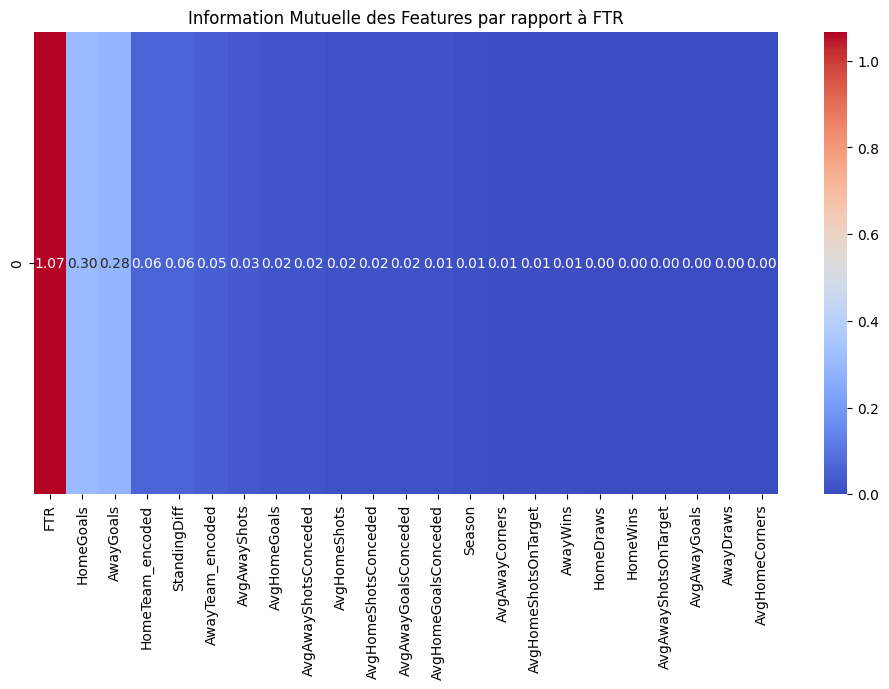


Importance des features par information mutuelle:
FTR                     1.065644
HomeGoals               0.304067
AwayGoals               0.284289
HomeTeam_encoded        0.061608
StandingDiff            0.059562
AwayTeam_encoded        0.047551
AvgAwayShots            0.034905
AvgHomeGoals            0.022606
AvgAwayShotsConceded    0.021534
AvgHomeShots            0.016528
AvgHomeShotsConceded    0.015650
AvgAwayGoalsConceded    0.015521
AvgHomeGoalsConceded    0.013534
Season                  0.009986
AvgAwayCorners          0.008209
AvgHomeShotsOnTarget    0.007027
AwayWins                0.005527
HomeDraws               0.002656
HomeWins                0.000747
AvgAwayShotsOnTarget    0.000000
AvgAwayGoals            0.000000
AwayDraws               0.000000
AvgHomeCorners          0.000000
dtype: float64


In [48]:
# Normaliser les données pour que chaque colonne soit entre 0 et 1
df_normalized = (df_results_encoded - df_results_encoded.min()) / (df_results_encoded.max() - df_results_encoded.min())

# Convertir FTR en format numérique
df_results_encoded['FTR'] = df_results_encoded['FTR'].astype('category').cat.codes

X = df_numeric
y = df_results['FTR']

# Calculer l'information mutuelle
importance_features = mutual_info_classif(X, y)
feature_importance = pd.Series(importance_features, index=X.columns)

# Trier par ordre d'importance
feature_importance_sorted = feature_importance.sort_values(ascending=False)

# Affichage sous forme de heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(feature_importance_sorted.to_frame().T, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Information Mutuelle des Features par rapport à FTR")
plt.show()

print("\nImportance des features par information mutuelle:")
print(feature_importance_sorted)


##### D'apres l'information mutuelle, nous allons créer un deuxieme dataframe en enlevant les caractéristiques HomeDraws, AwayDraws, AvgAwayShotsOnTarget, AvgAwayGoals, AvgHomeCorners

In [49]:
# Liste des variables à éliminer
variables_a_supprimer = ["HomeDraws", "AwayDraws", "AvgAwayShotsOnTarget", "AvgAwayGoals", "AvgHomeCorners"]

# Création d'un nouveau DataFrame sans ces variables
df_results_encoded_filtered = df_results.drop(columns=variables_a_supprimer)

In [50]:
df_results_encoded_filtered

,Season,HomeTeam,AwayTeam,FTR,HomeGoals,AwayGoals,StandingDiff,HomeWins,AwayWins,AvgHomeGoals,...,AvgAwayShots,AvgHomeShotsOnTarget,AvgAwayCorners,AvgHomeGoalsConceded,AvgAwayGoalsConceded,AvgHomeShotsConceded,AvgAwayShotsConceded,Year,Month,Day
0,0,0,32,2,3,0,-7,80.0,40.0,1.8,...,9.6,8.8,5.4,0.8,1.6,7.8,12.2,2011,11,5
1,0,1,22,2,3,2,-9,40.0,20.0,1.4,...,11.6,4.6,4.8,0.8,1.6,11.2,16.6,2011,11,5
2,0,2,9,0,0,1,13,20.0,40.0,1.2,...,18.2,6.2,6.8,2.4,1.2,14.8,10.8,2011,11,5
3,0,17,29,1,0,0,-12,40.0,0.0,1.6,...,10.2,8.4,6.4,1.0,2.8,11.0,18.8,2011,11,5
4,0,19,28,2,1,0,-9,80.0,20.0,3.4,...,13.0,12.0,4.8,1.8,1.0,18.2,14.4,2011,11,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3826,10,11,21,2,1,0,-2,20.0,60.0,1.0,...,14.0,4.2,5.4,1.2,0.6,10.8,10.4,2022,3,17
3827,10,35,15,0,2,3,4,60.0,20.0,1.8,...,12.6,4.4,5.4,1.0,3.0,12.6,15.6,2022,3,18
3828,10,1,0,0,0,1,3,20.0,80.0,2.0,...,15.0,4.8,4.2,1.8,1.0,11.6,10.4,2022,3,19
3829,10,16,5,2,2,1,-13,40.0,20.0,1.4,...,6.6,3.2,2.0,1.2,2.4,17.8,18.6,2022,3,20


### 4. Analyse du fichier EPL_processed_results après modification

In [51]:
# Calcul de l'entropie sur le nouveau DataFrame
df_numeric_filtered = df_results_encoded_filtered.select_dtypes(include=[np.number])
df_normalized_filtered = (df_numeric_filtered - df_numeric_filtered.min()) / (df_numeric_filtered.max() - df_numeric_filtered.min())
entropie_totale_filtered = np.sum(entropy(df_normalized_filtered.T))
print(f" Entropie totale du dataset filtré : {entropie_totale_filtered:.4f}")


 Entropie totale du dataset filtré : 10780.6537


##### Analyse de l'Entropie
- Entropie avant modification : 11 581.98
- Entropie après suppression des variables peu informatives** : 10780.6537
- Perte d'information:
$$
  \frac{11 581.98 - 10 780.6537}{11 581.98} \times 100 \approx 7,0\%
$$ 
 Interprétation :  
La suppression des caractéristiques peu informatives a entraîné une perte d'information relativement faible (7.0%), ce qui est tout à fait acceptable dans un processus de réduction de dimensionnalité.


##### Impact de la Réduction de Dimensionnalité
Nous avons supprimé les variables ayant une faible information mutuelle avec `FTR`, notamment :
- AwayDraws
- AvgHomeCorners
- AvgAwayCorners
- AvgHomeShotsConceded

 
Une perte inférieure à 10% est généralement considérée comme normale lorsqu’on réduit la dimensionnalité.
Ces variables n’apportaient pas de contribution significative à la prédiction du résultat du match (`FTR`).

In [53]:
from IPython.display import FileLink

FileLink("df_results_filtered.csv")

/home/mandchouno/EPL_Project/notebooks/df_results_filtered.csv

### 5. Répartition des classes 

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/tmp/ipykernel_5621/176313949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FTR', data=df, palette='Set2')
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


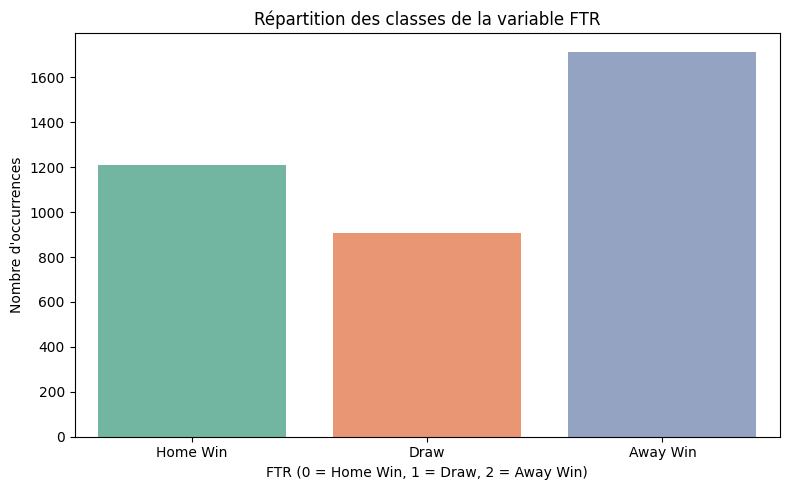

In [54]:
# Charger le fichier CSV contenant les données filtrées
df = pd.read_csv("df_results_filtered.csv")

# Affichage de la répartition des classes
plt.figure(figsize=(8, 5))
sns.countplot(x='FTR', data=df, palette='Set2')
plt.title("Répartition des classes de la variable FTR")
plt.xlabel("FTR (0 = Home Win, 1 = Draw, 2 = Away Win)")
plt.ylabel("Nombre d'occurrences")
plt.xticks([0, 1, 2], ['Home Win', 'Draw', 'Away Win'])
plt.tight_layout()
plt.show()

In [55]:
df.columns.tolist()

['HomeTeam',
 'AwayTeam',
 'FTR',
 'HomeGoals',
 'AwayGoals',
 'StandingDiff',
 'HomeWins',
 'AwayWins',
 'AvgHomeGoals',
 'AvgAwayGoals',
 'AvgHomeShots',
 'AvgAwayShots',
 'AvgHomeShotsOnTarget',
 'AvgAwayShotsOnTarget',
 'AvgHomeCorners',
 'AvgAwayCorners',
 'AvgHomeGoalsConceded',
 'AvgAwayGoalsConceded',
 'AvgHomeShotsConceded',
 'AvgAwayShotsConceded',
 'Year',
 'Day']

In [56]:
df = pd.read_csv("../data/df_results_filtered.csv")
print("Répartition initiale des classes :")
print(df["FTR"].value_counts())

Répartition initiale des classes :
FTR
2    1713
0    1210
1     908
Name: count, dtype: int64


### SMOTE (Synthetic Minority Over-sampling Technique) pour rééquilibrer les classes

Principe :
- Génère artificiellement de nouveaux exemples dans les classes minoritaires en interpolant les points existants.

Avantages :
- Très utile lorsque les classes minoritaires sont très sous-représentées.
- Évite la perte d’information causée par le sous-échantillonnage.

Inconvénients :
- Risque d’overfitting car on ajoute des données synthétiques proches des données réelles.
- Ne tient pas compte du déséquilibre au niveau de la structure du problème (juste du volume).

In [57]:
X = df.drop(columns=["FTR"])
y = df["FTR"]

# Appliquer SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

from collections import Counter
print(" Nouvelle répartition après SMOTE :", Counter(y_resampled))

 Nouvelle répartition après SMOTE : Counter({2: 1713, 0: 1713, 1: 1713})


In [58]:

df_resampled = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), 
                          pd.Series(y_resampled, name="FTR")], axis=1)

df_resampled.to_csv("df_results_smote.csv", index=False)

print(" Fichier sauvegardé sous le nom 'df_results_smote.csv'")

 Fichier sauvegardé sous le nom 'df_results_smote.csv'


### 6. Supprimer ou transformer les variables très corrélées

In [ ]:
df_results3 = df_results_encoded


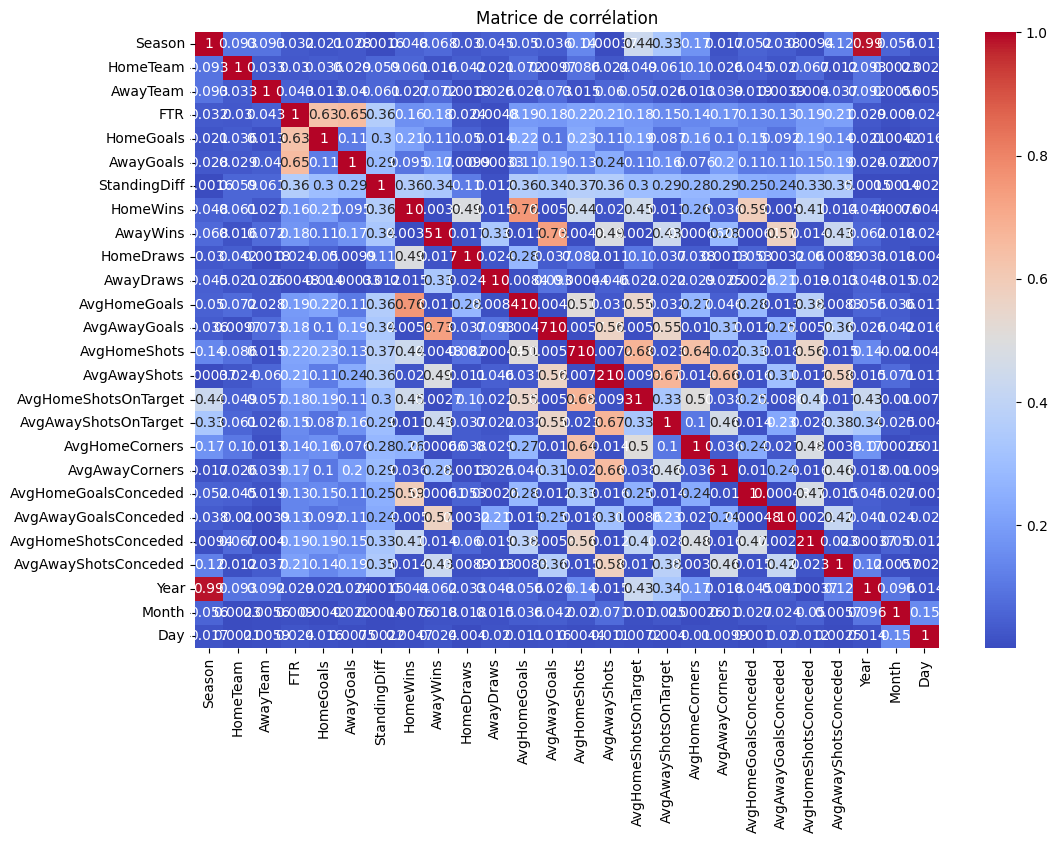

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

# Corrélation entre les variables numériques
corr_matrix = df_results3.corr().abs()

# Affichage des corrélations
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

In [86]:
cols_to_drop = [
    'Year',
    'AvgHomeShotsOnTarget', 
    'AvgAwayShotsOnTarget',  
    'AvgHomeGoalsConceded',  
    'AvgAwayGoalsConceded', 
    'HomeGoals'              
]

df_cleaned = df_results3.drop(columns=cols_to_drop)

# Modélisation
Maintenant que nous avons un dataset optimisé avec des caractéristiques pertinentes, nous pouvons passer à la construction du modèle de classification pour prédire `FTR`.


### 1. Classificateur de bayes naif classique

In [87]:

X = df_cleaned.drop(columns=['FTR']) 
y = df_cleaned['FTR']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.70      0.69       381
           1       0.31      0.24      0.27       269
           2       0.66      0.72      0.69       500

    accuracy                           0.60      1150
   macro avg       0.55      0.55      0.55      1150
weighted avg       0.58      0.60      0.59      1150



### 2. Classificateur de Bayes naif classique (avec rééquilibrage de classe)

In [88]:
# Supprimer les colonnes très corrélées
cols_to_drop = [
    'Year',
    'AvgHomeShotsOnTarget',
    'AvgAwayShotsOnTarget',
    'AvgHomeGoalsConceded',
    'AvgAwayGoalsConceded',
    'HomeGoals'
]
df_cleaned = df_results3.drop(columns=cols_to_drop)

#  Séparer les features et la cible
X = df_cleaned.drop(columns=['FTR'])
y = df_cleaned['FTR']

# Découper en train/test AVANT SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Appliquer SMOTE uniquement sur les données d'entraînement
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Entraîner Naive Bayes
model = GaussianNB()
model.fit(X_train_resampled, y_train_resampled)
y_pred = model.predict(X_test)

# Évaluer
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.69      0.68       363
           1       0.33      0.49      0.40       273
           2       0.73      0.54      0.62       514

    accuracy                           0.57      1150
   macro avg       0.58      0.57      0.57      1150
weighted avg       0.62      0.57      0.59      1150



### 3. Naive Bayes multinomial calibré 

#### a. Naive Bayes multinomial calibré isotonique avec test du calibrage sigmoid

              precision    recall  f1-score   support

           0       0.68      0.68      0.68       363
           1       0.33      0.51      0.40       273
           2       0.74      0.53      0.62       514

    accuracy                           0.57      1150
   macro avg       0.58      0.57      0.56      1150
weighted avg       0.62      0.57      0.58      1150



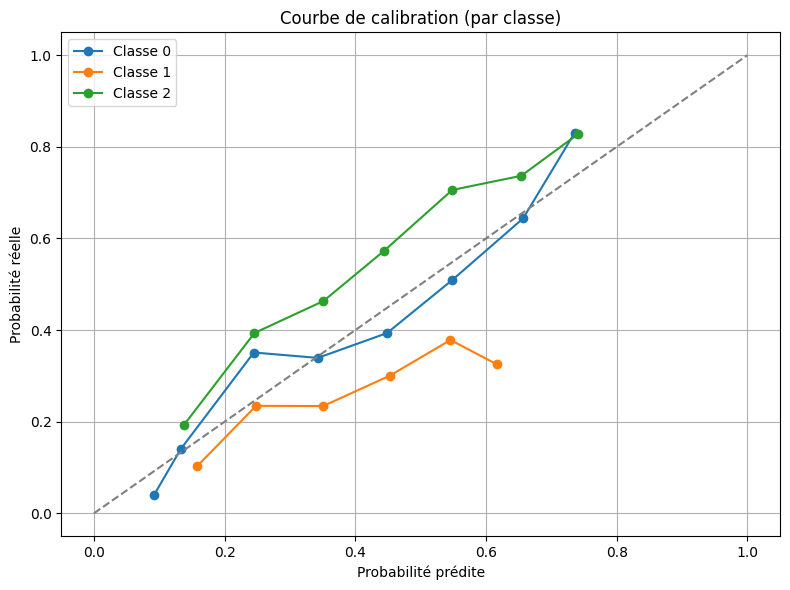

In [94]:
# Nettoyage 
cols_to_drop = [
    'Year',
    'AvgHomeShotsOnTarget',
    'AvgAwayShotsOnTarget',
    'AvgHomeGoalsConceded',
    'AvgAwayGoalsConceded',
    'HomeGoals'
]
df_cleaned = df_results3.drop(columns=cols_to_drop)

# Séparer features / cible
X = df_cleaned.drop(columns=['FTR'])
y = df_cleaned['FTR']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Naive Bayes avec calibration
base_model = GaussianNB()
calibrated_model = CalibratedClassifierCV(GaussianNB(), method='sigmoid', cv=5)
calibrated_model.fit(X_train_res, y_train_res)

# Prédictions
y_pred = calibrated_model.predict(X_test)
print(classification_report(y_test, y_pred))
# Courbe de calibration
plt.figure(figsize=(8, 6))

# Pour chaque classe (ex: H, D, A), afficher la courbe de calibration
classes = calibrated_model.classes_

for i, label in enumerate(classes):
    y_prob = calibrated_model.predict_proba(X_test)[:, i]
    y_bin = (y_test == label).astype(int)

    prob_true, prob_pred = calibration_curve(y_bin, y_prob, n_bins=10, strategy='uniform')
    plt.plot(prob_pred, prob_true, marker='o', label=f'Classe {label}')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Probabilité prédite')
plt.ylabel('Probabilité réelle')
plt.title('Courbe de calibration (par classe)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

#### b. Naive Bayes multinomial calibré isotonique avec test du calibrage isotonic

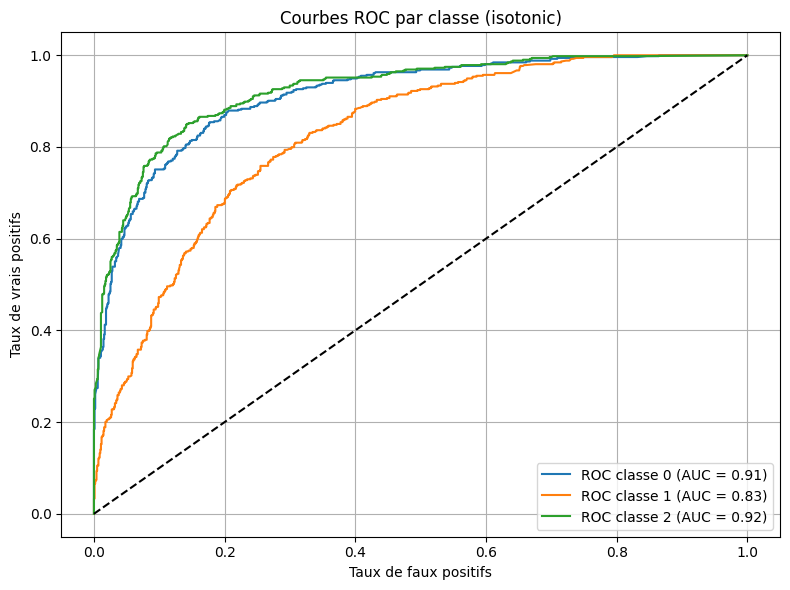

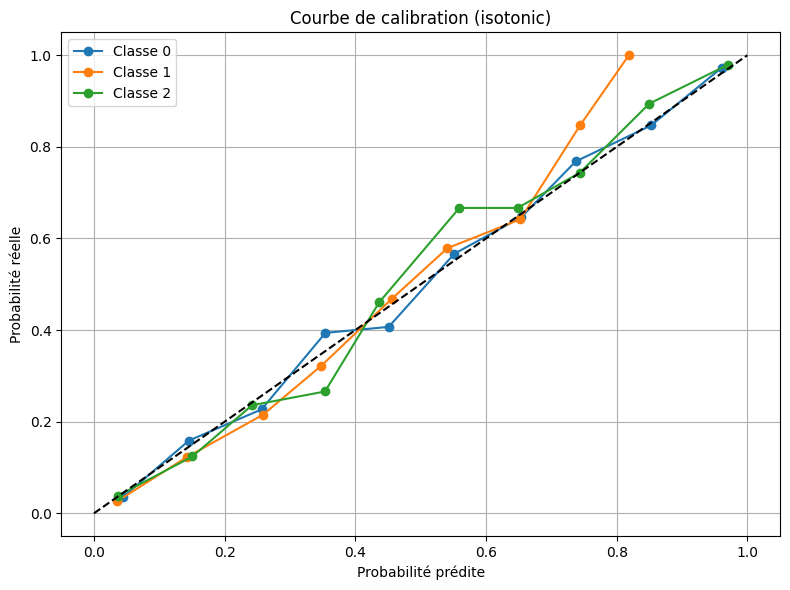

In [69]:

df_results_smote = pd.read_csv("df_results_smote.csv")

# Séparer les variables
X = df_results_smote.drop(columns=['FTR'])  # Adapter si le nom de la cible est différent
y = df_results_smote['FTR']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Modèle Naive Bayes avec calibration isotonic
model = CalibratedClassifierCV(GaussianNB(), method='isotonic', cv=5)
model.fit(X_train, y_train)

# Étape 4 : Prédictions
y_prob = model.predict_proba(X_test)
classes = model.classes_


# courbe ROC par calsse

y_test_bin = label_binarize(y_test, classes=classes)

fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i, label in enumerate(classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC classe {label} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC par classe (isotonic)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# courbe de calibration

plt.figure(figsize=(8, 6))
for i, label in enumerate(classes):
    prob_true, prob_pred = calibration_curve((y_test == label).astype(int), y_prob[:, i], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=f'Classe {label}')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Probabilité prédite')
plt.ylabel('Probabilité réelle')
plt.title('Courbe de calibration (isotonic)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

La calibration isotonique (isotonic regression) offre une plus grande flexibilité que la calibration sigmoïde (Platt scaling), car elle ne suppose aucune forme fonctionnelle spécifique entre les probabilités prédites et les probabilités réelles. Là où la sigmoïde impose une courbe en S (logistique), l’isotonic peut s’adapter librement à des courbes en escalier ou irrégulières, capturant plus finement les écarts de calibration dans chaque classe.

Dans les graphiques, on constate :
- La courbe isotonique suit de manière plus fidèle la diagonale idéale (y = x), surtout pour les classes minoritaires.
- La calibration sigmoïde est globalement trop rigide, ce qui peut engendrer une sous-estimation ou surestimation systématique dans certaines plages de probabilité.

Ainsi, pour des modèles multiclasses ou des distributions complexes comme dans la Premier League, l’isotonic offre une calibration plus réaliste, améliorant la qualité interprétative des probabilités.

#### c. Resultat du naive Bayes multinomial calibré isotonique avec test du calibrage isotonic

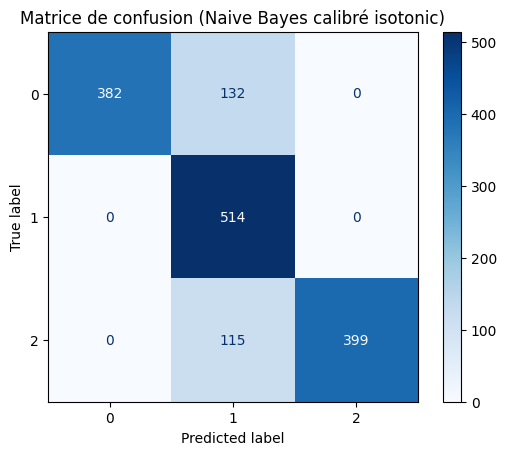

===== Rapport de classification =====
              precision    recall  f1-score   support

           0       1.00      0.74      0.85       514
           1       0.68      1.00      0.81       514
           2       1.00      0.78      0.87       514

    accuracy                           0.84      1542
   macro avg       0.89      0.84      0.84      1542
weighted avg       0.89      0.84      0.84      1542

Exactitude (accuracy) : 0.840
Exactitude équilibrée : 0.840
Log Loss : 0.413
Précision macro : 0.892
Rappel macro : 0.840
F1-score macro : 0.844
Précision micro : 0.840
Rappel micro : 0.840
F1-score micro : 0.840
AUC ROC macro : 0.933
AUC ROC micro : 0.953


In [83]:

# Prédictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues')
plt.title("Matrice de confusion (Naive Bayes calibré isotonic)")
plt.grid(False)
plt.show()

# Rapport complet
print("===== Rapport de classification =====")
print(classification_report(y_test, y_pred))

# Accuracy
acc = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Exactitude (accuracy) : {acc:.3f}")
print(f"Exactitude équilibrée : {bal_acc:.3f}")

# Log loss
logloss = log_loss(y_test, y_prob)
print(f"Log Loss : {logloss:.3f}")

# Metriques
print(f"Précision macro : {precision_score(y_test, y_pred, average='macro'):.3f}")
print(f"Rappel macro : {recall_score(y_test, y_pred, average='macro'):.3f}")
print(f"F1-score macro : {f1_score(y_test, y_pred, average='macro'):.3f}")

print(f"Précision micro : {precision_score(y_test, y_pred, average='micro'):.3f}")
print(f"Rappel micro : {recall_score(y_test, y_pred, average='micro'):.3f}")
print(f"F1-score micro : {f1_score(y_test, y_pred, average='micro'):.3f}")

# ROC AUC par classe
y_test_bin = label_binarize(y_test, classes=classes)
roc_auc_macro = roc_auc_score(y_test_bin, y_prob, average='macro')
roc_auc_micro = roc_auc_score(y_test_bin, y_prob, average='micro')

print(f"AUC ROC macro : {roc_auc_macro:.3f}")
print(f"AUC ROC micro : {roc_auc_micro:.3f}")

### 4. Optimisation alpha pour le Naive Bayes multinomial calibré isotonique avec test du calibrage isotonic

Alpha est un paramtre de lissage afin d'eviter les probabilités nulles.

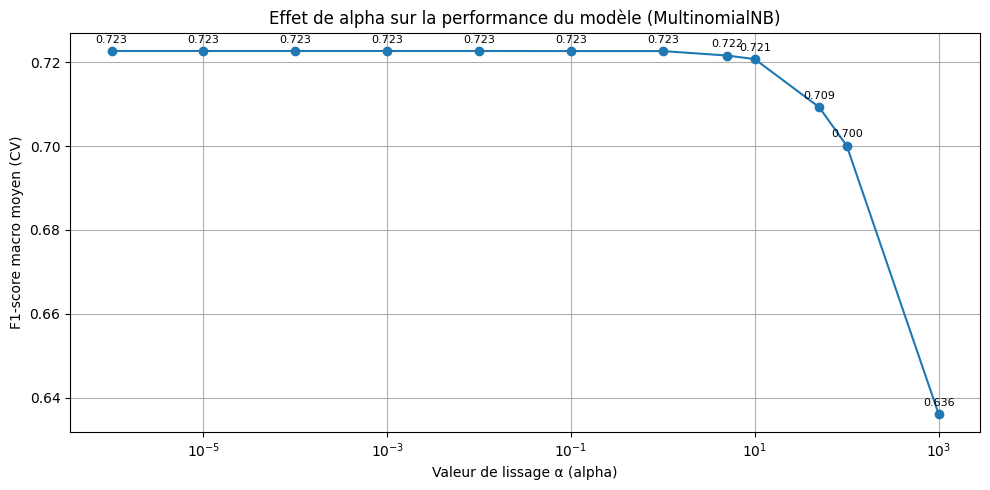

Meilleur alpha : 1e-06


In [97]:
# Préparation des données
X = df_results_smote.drop(columns=['FTR'])
y = df_results_smote['FTR']

# Discrétisation
discretizer = KBinsDiscretizer(n_bins=6, encode='ordinal', strategy='uniform')
X_disc = discretizer.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_disc, y, stratify=y, test_size=0.3, random_state=42)

# Grille étendue pour alpha
param_grid = {'alpha': [
    1e-6, 1e-5, 1e-4, 1e-3,
    1e-2, 1e-1,
    1, 5, 10, 50, 100, 1000
]}

# GridSearchCV
grid = GridSearchCV(MultinomialNB(), param_grid, scoring='f1_macro', cv=5)
grid.fit(X_train, y_train)

# Résultats
best_model = grid.best_estimator_
alphas_tested = grid.cv_results_['param_alpha'].data
f1_scores = grid.cv_results_['mean_test_score']

# Évaluation sur le test set
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)


# Courbe F1 vs alpha
plt.figure(figsize=(10, 5))
plt.plot(alphas_tested, f1_scores, marker='o')
plt.xscale('log')
plt.xlabel("Valeur de lissage α (alpha)")
plt.ylabel("F1-score macro moyen (CV)")
plt.title("Effet de alpha sur la performance du modèle (MultinomialNB)")
plt.grid(True)

# Ajouter les valeurs sur le graphique
for a, f1 in zip(alphas_tested, f1_scores):
    plt.text(a, f1 + 0.002, f"{f1:.3f}", fontsize=8, ha='center')

plt.tight_layout()
plt.show()

print("Meilleur alpha :", grid.best_params_['alpha'])


### 5. Multinomial Naive Bayes avec optimisation alpha et calibration isotonique

===== Rapport de classification =====
              precision    recall  f1-score   support

           0       0.86      0.74      0.79       514
           1       0.62      0.79      0.69       514
           2       0.86      0.75      0.80       514

    accuracy                           0.76      1542
   macro avg       0.78      0.76      0.76      1542
weighted avg       0.78      0.76      0.76      1542

Log Loss : 0.6168775811538239
AUC ROC macro : 0.893710856081596
AUC ROC micro : 0.9030342161795704


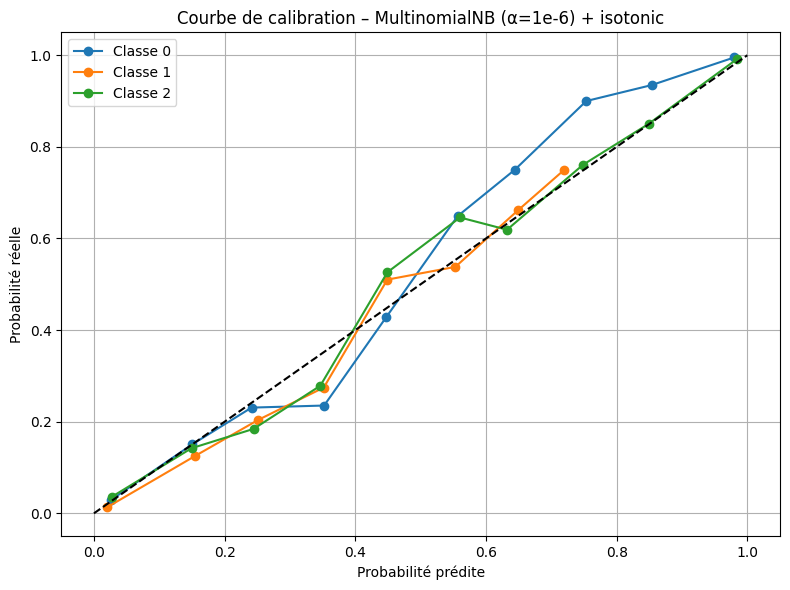

In [98]:
# Préparer les données
X = df_results_smote.drop(columns=['FTR'])
y = df_results_smote['FTR']

# Discrétisation
discretizer = KBinsDiscretizer(n_bins=6, encode='ordinal', strategy='uniform')
X_disc = discretizer.fit_transform(X)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X_disc, y, stratify=y, test_size=0.3, random_state=42)

#  Modèle avec calibration isotonic
base_model = MultinomialNB(alpha=1e-6)
calibrated_model = CalibratedClassifierCV(base_model, method='isotonic', cv=5)
calibrated_model.fit(X_train, y_train)

#  Prédictions
y_pred = calibrated_model.predict(X_test)
y_prob = calibrated_model.predict_proba(X_test)

#  Évaluation
print("===== Rapport de classification =====")
print(classification_report(y_test, y_pred))
print("Log Loss :", log_loss(y_test, y_prob))

# Binariser pour AUC ROC
y_test_bin = label_binarize(y_test, classes=calibrated_model.classes_)
roc_auc_macro = roc_auc_score(y_test_bin, y_prob, average='macro')
roc_auc_micro = roc_auc_score(y_test_bin, y_prob, average='micro')

print("AUC ROC macro :", roc_auc_macro)
print("AUC ROC micro :", roc_auc_micro)

# Courbe de calibration
y_true_bin = pd.get_dummies(y_test)
y_prob_df = pd.DataFrame(y_prob)

plt.figure(figsize=(8, 6))
for i in y_prob_df.columns:
    prob_true, prob_pred = calibration_curve(y_true_bin[i], y_prob_df[i], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=f'Classe {i}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Courbe de calibration – MultinomialNB (α=1e-6) + isotonic")
plt.xlabel("Probabilité prédite")
plt.ylabel("Probabilité réelle")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

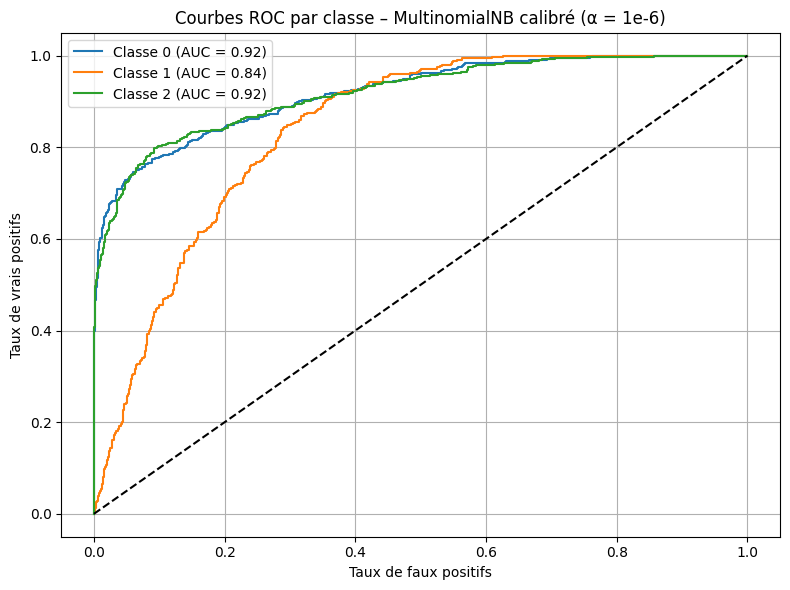

In [92]:

fpr = dict()
tpr = dict()
roc_auc = dict()

for i, label in enumerate(calibrated_model.classes_):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Tracer les courbes
plt.figure(figsize=(8, 6))
for i, label in enumerate(calibrated_model.classes_):
    plt.plot(fpr[i], tpr[i], label=f"Classe {label} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC par classe – MultinomialNB calibré (α = 1e-6)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### 6. Réseau bayésien non naïf 

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'FTR': 'N', 'StandingDiff': 'N', 'AvgHomeGoals': 'N', 'AvgAwayGoals': 'N', 'AvgHomeShots': 'N', 'AvgAwayShots': 'N'}


              precision    recall  f1-score   support

           0       0.57      0.47      0.52      1713
           1       0.45      0.54      0.49      1713
           2       0.56      0.54      0.55      1713

    accuracy                           0.52      5139
   macro avg       0.53      0.52      0.52      5139
weighted avg       0.53      0.52      0.52      5139

Log Loss : 0.9470581958007861


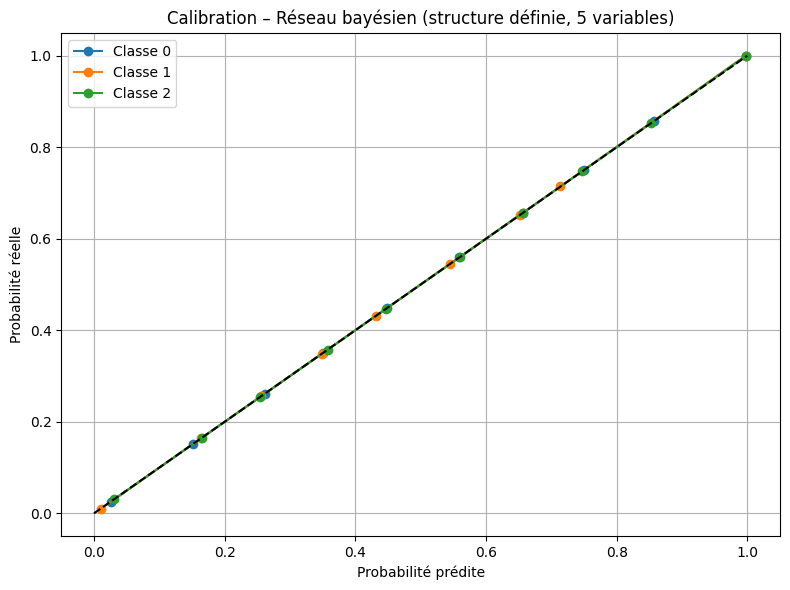

In [89]:
# Sélection des 5 variables les plus informatives
selected_features = ["StandingDiff", "AvgHomeGoals", "AvgAwayGoals", "AvgHomeShots", "AvgAwayShots"]
df_bayes = df_results_smote[["FTR"] + selected_features].copy()

# Discrétisation des variables
discretizer = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='uniform')
df_bayes[selected_features] = discretizer.fit_transform(df_bayes[selected_features])

# Structure manuelle du réseau
edges = [(col, "FTR") for col in selected_features]
model = BayesianNetwork(edges)

# Estimation des paramètres
model.fit(df_bayes, estimator=BayesianEstimator)

# Inférence
inference = VariableElimination(model)

# Prédictions
X = df_bayes.drop(columns=["FTR"])
y_true = df_bayes["FTR"]
y_pred = []
y_prob = []

for _, row in X.iterrows():
    query = inference.query(variables=["FTR"], evidence=row.to_dict(), show_progress=False)
    y_prob.append([query.values[i] for i in range(len(query.values))])
    y_pred.append(query.values.argmax())

# Évaluation
y_pred = pd.Series(y_pred)
print(classification_report(y_true, y_pred))
print("Log Loss :", log_loss(y_true, y_prob))

# Calibration
y_true_bin = pd.get_dummies(y_true)
y_prob = pd.DataFrame(y_prob)

plt.figure(figsize=(8, 6))
for i in y_prob.columns:
    prob_true, prob_pred = calibration_curve(y_true_bin[i], y_prob[i], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=f'Classe {i}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Calibration – Réseau bayésien (structure définie, 5 variables)")
plt.xlabel("Probabilité prédite")
plt.ylabel("Probabilité réelle")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Le réseau bayésien non naïf, construit avec une structure manuelle sur cinq variables sélectionnées, montre des résultats très limités. Les métriques globales sont faibles : un F1-score moyen de 0.52, une précision de 0.53 et un rappel de 0.52, pour chaque classe. Le log loss est élevé (0.947), indiquant une mauvaise calibration des probabilités.

Même après calibration, le modèle reste peu fiable. Cela s’explique par la forte simplification du réseau (seulement 5 variables et une structure manuelle), combinée à la nature discrète du modèle qui ne capture pas bien la complexité des interactions entre variables continues. En résumé, ce modèle montre que la qualité de la structure du graphe et le nombre de variables sont critiques pour la performance d’un réseau bayésien

# Travaux connexes

### 7. régression logistique multinomiale pondérée

La calibration permet d’ajuster les probabilités prédites pour qu’elles reflètent fidèlement la réalité. Elle est particulièrement utile lorsque les probabilités brutes du modèle ne sont pas alignées avec les fréquences observées. Deux méthodes sont couramment utilisées : la calibration sigmoïde (Platt), plus rigide, et la calibration isotonique, plus flexible et performante sur de larges ensembles de données.

En parallèle, lorsqu’un déséquilibre de classes est présent, la pondération des classes (via class_weight='balanced') permet de corriger ce biais en accordant plus de poids aux classes minoritaires. Cela améliore la capacité du modèle à bien prédire toutes les classes, même celles sous-représentées.

La combinaison d’une régression pondérée avec une calibration (comme l’isotonique) offre donc une solution robuste : elle améliore à la fois la répartition équitable des prédictions et la qualité des probabilités estimées.

Poids de classes : {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0), np.int64(2): np.float64(1.0)}
===== Rapport de classification =====
              precision    recall  f1-score   support

           0       1.00      0.74      0.85       514
           1       0.68      1.00      0.81       514
           2       1.00      0.78      0.87       514

    accuracy                           0.84      1542
   macro avg       0.89      0.84      0.84      1542
weighted avg       0.89      0.84      0.84      1542

Log Loss : 0.41331087013008483
AUC ROC macro : 0.9331418088590794
AUC ROC micro : 0.9529404516175701


/localscratch/mandchouno.2102.0/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


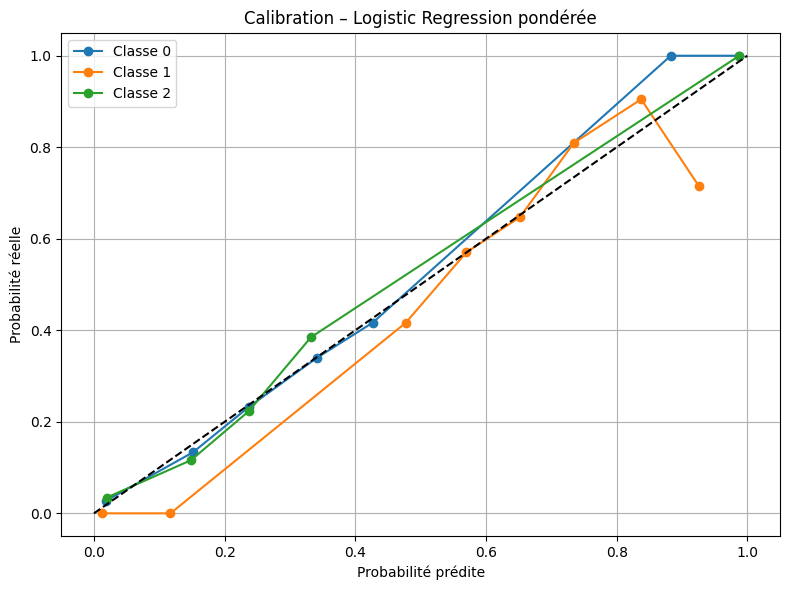

In [76]:
# Préparer les données
X = df_results_smote.drop(columns=['FTR'])
y = df_results_smote['FTR']

# Discrétisation
discretizer = KBinsDiscretizer(n_bins=6, encode='ordinal', strategy='uniform')
X_disc = discretizer.fit_transform(X)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X_disc, y, stratify=y, test_size=0.3, random_state=42)

# Calcul automatique des poids
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
weights_dict = {cls: w for cls, w in zip(np.unique(y_train), class_weights)}
print("Poids de classes :", weights_dict)

#  Modèle avec pondération
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, class_weight=weights_dict)
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

print("===== Rapport de classification =====")
print(classification_report(y_test, y_pred))
print("Log Loss :", log_loss(y_test, y_prob))

# AUC
y_test_bin = label_binarize(y_test, classes=model.classes_)
print("AUC ROC macro :", roc_auc_score(y_test_bin, y_prob, average='macro'))
print("AUC ROC micro :", roc_auc_score(y_test_bin, y_prob, average='micro'))

# Calibration
y_true_bin = pd.get_dummies(y_test)
y_prob_df = pd.DataFrame(y_prob)

plt.figure(figsize=(8, 6))
for i in y_prob_df.columns:
    prob_true, prob_pred = calibration_curve(y_true_bin[i], y_prob_df[i], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=f'Classe {i}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Calibration – Logistic Regression pondérée")
plt.xlabel("Probabilité prédite")
plt.ylabel("Probabilité réelle")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Calibration : 
- Toutes les courbes sont très proches de la diagonale ➜ les probabilités sont bien calibrées.
- On as un modèle très honnête dans ses prédictions


Performances de classification : 
- Le modèle prédit correctement à 52 %, ce qui est en dessous de ton Naive Bayes calibré isotonic (~74 %)
- Les f1-scores restent équilibrés (~0.5) mais faibles pour un usage final.
